In [1]:
import wbgapi as wb
import pandas as pd

# 1. Define the specific countries (ISO-3 codes)
# You can also use 'LCN' for the entire Latin America & Caribbean region aggregate
countries = [
    "ARG", "BOL", "BRA", "CHL", "COL", "CRI", "CUB", "DOM", "ECU", 
    "SLV", "GTM", "HTI", "HND", "MEX", "NIC", "PAN", "PRY", "PER", 
    "URY", "VEN"
]

# 2. Define the indicator for "GDP Growth (annual %)"
# Code: NY.GDP.MKTP.KD.ZG
indicator = 'NY.GDP.MKTP.KD.ZG'

# 3. Fetch the data
# date=1960 means "from 1960 to present"
print("Fetching data...")
data = wb.data.DataFrame(indicator, countries, time=range(1960, 2025), labels=True)

# 4. Reset index to make it easier to read/export
data = data.reset_index()

# 5. Display and Save
print(data.head())
data.to_csv('latin_america_gdp_growth.csv', index=False)
print("Data saved to 'latin_america_gdp_growth.csv'")

Fetching data...
  economy        Country  YR1960     YR1961     YR1962    YR1963     YR1964  \
0     VEN  Venezuela, RB     NaN   3.192519   8.532934  3.900951  11.129345   
1     URY        Uruguay     NaN   2.493038  -1.574549  0.170459   2.440521   
2     PER           Peru     NaN   7.347096  10.035293  4.328250   6.547868   
3     PRY       Paraguay     NaN   6.900286   3.300259  4.710291   4.212477   
4     PAN         Panama     NaN  10.926595   8.244737  8.538789   4.432130   

     YR1965    YR1966    YR1967  ...    YR2015     YR2016     YR2017  \
0  4.162867  1.510250  2.833869  ... -6.221371 -17.040335 -15.671409   
1  1.045604  3.062856 -3.656834  ...  0.370741   1.689798   1.740376   
2  5.621733  8.238920  3.852564  ...  3.252245   3.953319   2.518835   
3  6.167975  1.991503  9.150367  ...  2.957152   4.268026   4.810079   
4  9.160036  7.581402  8.552931  ...  5.266917   4.571967   5.744059   

      YR2018     YR2019     YR2020     YR2021     YR2022    YR2023    YR202

In [8]:
df = pd.read_csv('latin_america_gdp_growth.csv')
df.head()

,economy,Country,YR1960,YR1961,YR1962,YR1963,YR1964,YR1965,YR1966,YR1967,...,YR2015,YR2016,YR2017,YR2018,YR2019,YR2020,YR2021,YR2022,YR2023,YR2024
0,VEN,"Venezuela, RB",NaN,3.192519,8.532934,3.900951,11.129345,4.162867,1.510250,2.833869,...,-6.221371,-17.040335,-15.671409,-19.655342,-27.657968,-29.998570,0.955433,8.000913,4.001686,5.300000
1,URY,Uruguay,NaN,2.493038,-1.574549,0.170459,2.440521,1.045604,3.062856,-3.656834,...,0.370741,1.689798,1.740376,0.164778,0.928351,-7.357327,5.844273,4.486227,0.742129,3.108255
2,PER,Peru,NaN,7.347096,10.035293,4.328250,6.547868,5.621733,8.238920,3.852564,...,3.252245,3.953319,2.518835,3.969351,2.240632,-10.933307,13.362624,2.809034,-0.403242,3.303941
3,PRY,Paraguay,NaN,6.900286,3.300259,4.710291,4.212477,6.167975,1.991503,9.150367,...,2.957152,4.268026,4.810079,3.204250,-0.401855,-0.819785,4.016737,0.176038,4.999228,4.249960
4,PAN,Panama,NaN,10.926595,8.244737,8.538789,4.432130,9.160036,7.581402,8.552931,...,5.266917,4.571967,5.744059,3.918198,3.103068,-17.821230,16.467125,11.038548,7.166329,2.747885


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns



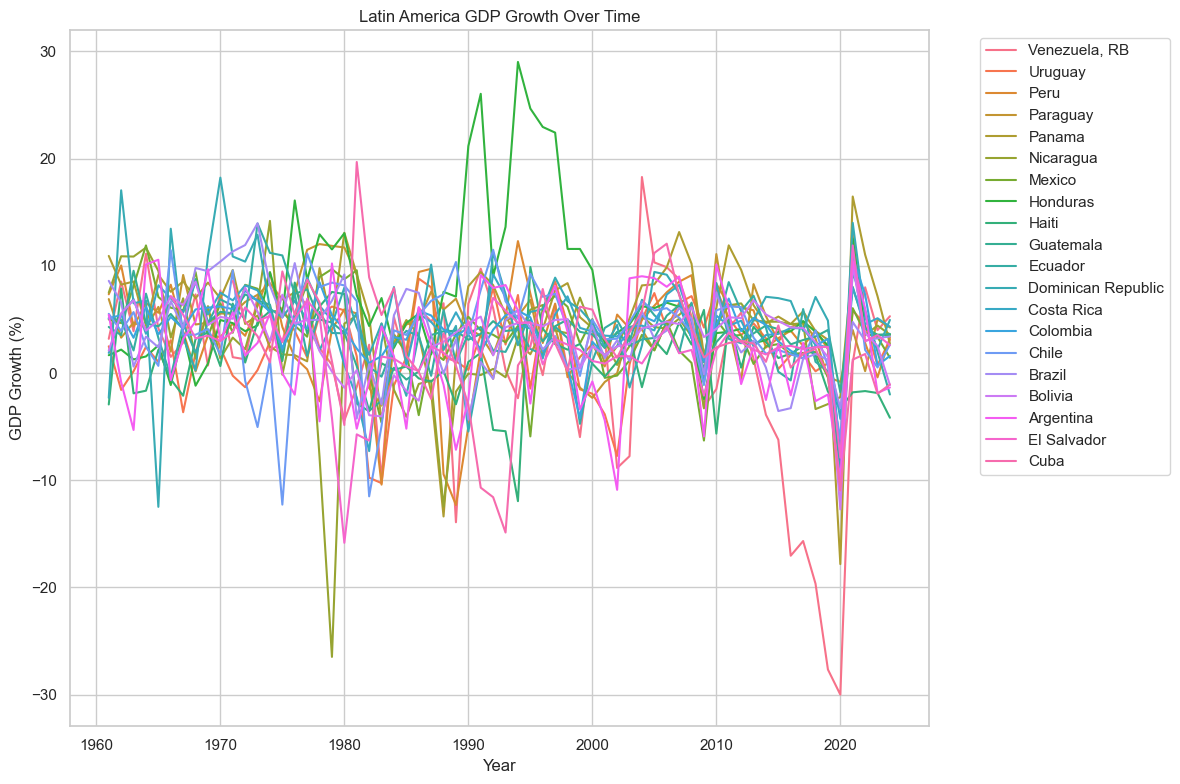

In [10]:
# Reshape the DataFrame from wide to long format
df_long = df.melt(id_vars=['economy', 'Country'], var_name='Year', value_name='GDP Growth')

# Clean the 'Year' column to be numeric
df_long['Year'] = df_long['Year'].str.replace('YR', '').astype(int)

# Drop rows with missing GDP Growth values
df_long = df_long.dropna(subset=['GDP Growth'])

# Create the line plot
plt.figure(figsize=(12, 8))
sns.lineplot(data=df_long, x='Year', y='GDP Growth', hue='Country')

# Add titles and labels
plt.title('Latin America GDP Growth Over Time')
plt.xlabel('Year')
plt.ylabel('GDP Growth (%)')

# Move the legend outside the plot area
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Save the plot
plt.savefig('latin_america_gdp_growth_lineplot.png')